<a href="https://colab.research.google.com/github/brianchinphd/ProviderProfilingSimulation/blob/main/ProviderProfilingSimulation_2023CMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Provider Profiling Simulation

This project uses the publicly available CMS dataset, *Medicare Physician & Other Practitioners - by Provider (2023)*, retrieved from https://data.cms.gov/.

**Problem:** How would we identify provider segments with cost/use variation for targeted action?

**Scope:** Connecticut anesthesiologists

In [3]:
# Import Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
cms = pd.read_csv('/content/Medicare_Physician_Other_Practitioners_by_Provider_2023.csv',low_memory=False)

In [4]:
# Generate New Dataframe
ct = cms[(cms['Rndrng_Prvdr_Type'] == 'Anesthesiology') & (cms['Rndrng_Prvdr_State_Abrvtn'] == 'CT')].copy()
display(ct.head())

print(f"The 'CT Anesthesiologist' DataFrame has {ct.shape[0]} entries.")

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
8029,1003807769,Hong,Sung-Chil,NaN,M.D.,I,111 Founders Plz,#300 C/O Ipms,East Hartford,CT,...,24%,28%,75%,75%,36%,18%,NaN,51%,NaN,1.4915
8961,1003836818,Anand,Suwarna,NaN,MD,I,333 Cedar Street,NaN,New Haven,CT,...,43%,46%,75%,75%,53%,15%,NaN,56%,17%,2.0476
9922,1003867649,Dennen,Phillip,NaN,MD,I,114 Woodland St,NaN,Hartford,CT,...,38%,26%,75%,75%,35%,22%,NaN,63%,13%,2.0457
9985,1003869462,Setter,Frank,J,MD,I,114 Woodland St,NaN,Hartford,CT,...,35%,27%,75%,75%,34%,12%,NaN,59%,9%,1.5492
10511,1003885773,Gorun-Gorunescu,Calin,NaN,MD,I,800 Howard Avenue,Yale Physicians Building,New Haven,CT,...,34%,27%,75%,75%,37%,15%,NaN,62%,11%,1.4611


The 'CT Anesthesiologist' DataFrame has 559 entries.


I will now examine provider variation in Tot_Mdcr_Stdzd_Amt, defined in the CMS Data Dictionary as the standardized amount paid after deductible/coinsurance (adjusted for geographic differences).

In [5]:
# Summarizing Per Provider Standardized Costs

# Clean and convert 'Tot_Mdcr_Stdzd_Amt' to numeric
ct['Tot_Mdcr_Stdzd_Amt'] = ct['Tot_Mdcr_Stdzd_Amt'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

# Re-calculate descriptive statistics
description = ct['Tot_Mdcr_Stdzd_Amt'].describe()
display(description)

,Tot_Mdcr_Stdzd_Amt
count,559.000000
mean,26445.125689
std,27596.154151
min,623.320000
25%,15440.850000
50%,22613.210000
75%,31373.540000
max,424118.690000


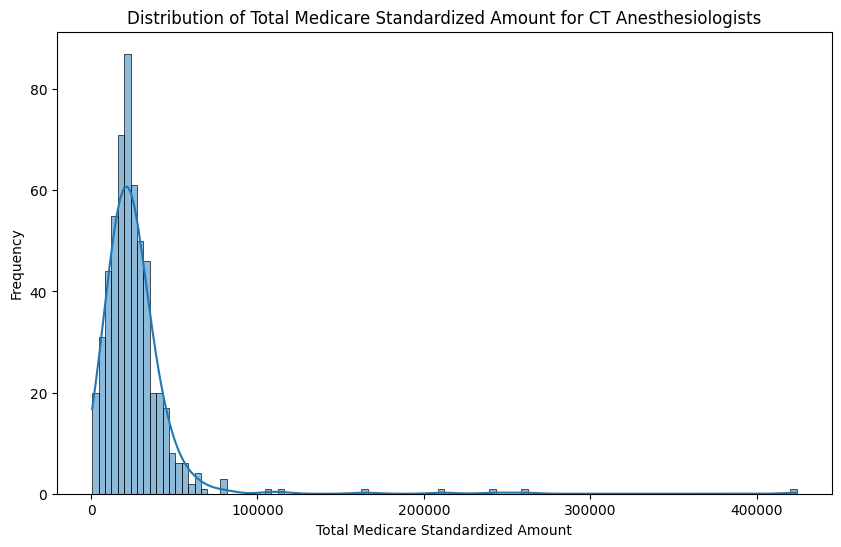

In [6]:
# Plot the distribution of total standardized costs in CT anesthesiologists
plt.figure(figsize=(10, 6))
sns.histplot(ct['Tot_Mdcr_Stdzd_Amt'], kde=True)
plt.title('Distribution of Total Medicare Standardized Amount for CT Anesthesiologists')
plt.xlabel('Total Medicare Standardized Amount')
plt.ylabel('Frequency')
plt.show()

In [7]:
# Check whether there are providers below a minimum number of beneficiaries (N = 30)
ct['Tot_Benes'] = ct['Tot_Benes'].astype(str).str.replace('[^0-9.]', '', regex=True).astype(float)

# Re-calculate descriptive statistics for Tot_Benes
description_tot_srvcs = ct['Tot_Benes'].describe()
display(description_tot_srvcs)

# How many providers would be dropped with minimum N of 30?
providers_less_than_30_services = ct[ct['Tot_Benes'] < 30]
num_providers_less_than_30 = len(providers_less_than_30_services)
print(f"Number of providers with less than 30 Beneficiaries: {num_providers_less_than_30}")

,Tot_Benes
count,559.000000
mean,186.787120
std,129.885748
min,11.000000
25%,102.000000
50%,164.000000
75%,236.500000
max,971.000000


Number of providers with less than 30 Beneficiaries: 21


In [8]:
# Make a new dataframe with only providers who meet the minimum N requirement
# Clean and convert 'Tot_Benes' to numeric
ctpaf = ct[ct['Tot_Benes'].astype(str).str.replace('[^0-9.]', '', regex=True).astype(float) >= 30].copy()

# Re-calculate descriptive statistics
description = ctpaf['Tot_Mdcr_Stdzd_Amt'].describe()
display(description)

,Tot_Mdcr_Stdzd_Amt
count,538.000000
mean,26851.718996
std,25873.155118
min,3108.080000
25%,16446.882500
50%,23142.755000
75%,31817.440000
max,424118.690000


Next, I calculated the primary profiling outcome measures:

1) Cost-per-beneficiary (Tot_Per_Bene): The ratio of the provider's total standardized amount to their total number of beneficiaries.
2) Cost-per-service (Tot_Per_Srvc): The ratio of the provider's total standardized amount to their total number of provided services.
3) Services-per-beneficiary (Srvc_Per_Bene): The ratio of a providers' provided services to beneficiaries.

In [27]:
ctpaf['Tot_Benes'] = ctpaf['Tot_Benes'].astype(str).str.replace('[^0-9.]', '', regex=True).astype(float)
ctpaf['Tot_Srvcs'] = ctpaf['Tot_Srvcs'].astype(str).str.replace('[^0-9.]', '', regex=True).astype(float)

ctpaf['Tot_Per_Bene'] = ctpaf['Tot_Mdcr_Stdzd_Amt'] / ctpaf['Tot_Benes']
ctpaf['Tot_Per_Srvc'] = ctpaf['Tot_Mdcr_Stdzd_Amt'] / ctpaf['Tot_Srvcs']
ctpaf['Srvc_Per_Bene'] = ctpaf['Tot_Srvcs'] / ctpaf['Tot_Benes']

average_tot_per_bene = ctpaf['Tot_Per_Bene'].mean()
std_tot_per_bene = ctpaf['Tot_Per_Bene'].std()
print(f"The average cost-per-beneficiary is: ${average_tot_per_bene:.2f} with SD of ${std_tot_per_bene:.2f}")

average_tot_per_srvc = ctpaf['Tot_Per_Srvc'].mean()
std_tot_per_srvc = ctpaf['Tot_Per_Srvc'].std()
print(f"The average cost-per-service is: ${average_tot_per_srvc:.2f} with SD of ${std_tot_per_srvc:.2f}")

average_srvc_per_bene = ctpaf['Srvc_Per_Bene'].mean()
std_srvc_per_bene = ctpaf['Srvc_Per_Bene'].std()
print(f"The average services-per-beneficiary is: ${average_srvc_per_bene:.2f} with SD of ${std_srvc_per_bene:.2f}")

The average cost-per-beneficiary is: $157.04 with SD of $105.01
The average cost-per-service is: $111.34 with SD of $42.64
The average services-per-beneficiary is: $2.07 with SD of $11.54


In [28]:
description = ctpaf['Tot_Per_Bene'].describe()
display(description)

,Tot_Per_Bene
count,538.00
mean,157.04
std,105.01
min,44.37
25%,100.39
50%,124.84
75%,174.51
max,977.67


**Cost-per-beneficiary** was used as the primary profiling outcome measure because it represents the total financial cost for a single patient and captures a provider's service intensity and utilization patterns."

538 eligible anesthesiologists in Connecticut had an average standardized cost per beneficiary of 157.04 USD.

Next, I used z-scoring to identify outlier providers on this metric.

In [14]:
# Calculate mean and standard deviation for 'Tot_Per_Bene'
mean_st_amt = ctpaf['Tot_Per_Bene'].mean()
std_st_amt = ctpaf['Tot_Per_Bene'].std()

# Z-score the variable
ctpaf['Tot_Per_Bene_Zscore'] = (ctpaf['Tot_Per_Bene'] - mean_st_amt) / std_st_amt
pd.set_option('display.float_format', '{:.2f}'.format)

# Display descriptive statistics for the z-scored variable
description_zscore = ctpaf['Tot_Per_Bene_Zscore'].describe()
display(description_zscore)

,Tot_Per_Bene_Zscore
count,538.00
mean,0.00
std,1.00
min,-1.07
25%,-0.54
50%,-0.31
75%,0.17
max,7.82


In [29]:
# Identify anesthesiologists in the Top 2.5% of standardized costs
ctpaf['High_Cost_Flag'] = ctpaf['Tot_Per_Bene_Zscore'] > 2

# Count how many providers have a z-score > 2
num_high_cost_providers = (ctpaf['Tot_Per_Bene_Zscore'] > 2).sum()
print(f"Number of providers with z-score > 2: {num_high_cost_providers}")

Number of providers with z-score > 2: 19


Next, I conducted a **root-cause analysis** of these providers to develop an actionable plan for addressing their high cost. This consisted of examining each provider's **patient acuity** (Bene_Avg_Risk_Scre), **unit pricing** (Tot_Per_Srvc), and **service intensity** (Srvc_Per_Bene).

In [31]:
# Get the average risk score in the population
average_risk_score = ctpaf['Bene_Avg_Risk_Scre'].mean()
std_risk_score = ctpaf['Bene_Avg_Risk_Scre'].std()
print(f"The average risk score is: {average_risk_score:.2f} (SD = {std_risk_score:.2f})")

The average risk score is: 1.61 (SD = 0.48)


In [35]:
# Calculate mean and standard deviation for each variable
mean_tot_per_srvc = ctpaf['Tot_Per_Srvc'].mean()
std_tot_per_srvc = ctpaf['Tot_Per_Srvc'].std()

mean_srvc_per_bene = ctpaf['Srvc_Per_Bene'].mean()
std_srvc_per_bene = ctpaf['Srvc_Per_Bene'].std()

mean_risk = ctpaf['Bene_Avg_Risk_Scre'].mean()
std_risk = ctpaf['Bene_Avg_Risk_Scre'].std()

# Z-score the variables
ctpaf['Tot_Per_Srvc_Zscore'] = (ctpaf['Tot_Per_Srvc'] - mean_tot_per_srvc) / std_tot_per_srvc
ctpaf['Srvc_Per_Bene_Zscore'] = (ctpaf['Srvc_Per_Bene'] - mean_srvc_per_bene) / std_srvc_per_bene
ctpaf['Bene_Avg_Risk_Scre_Zscore'] = (ctpaf['Bene_Avg_Risk_Scre'] - mean_risk) / std_risk
pd.set_option('display.float_format', '{:.2f}'.format)

In [49]:
# Examine the 19 flagged providers to diagnose the root cause of each high cost flag
high_cost_providers_data = ctpaf[ctpaf['High_Cost_Flag'] == True]

# Define root cause explanations and recommended intervention (if any)
conditions = [
    (ctpaf['Tot_Per_Bene_Zscore'] > 2) & (ctpaf['Bene_Avg_Risk_Scre_Zscore'] > 1), # High Acuity (No Action)
    (ctpaf['Srvc_Per_Bene_Zscore'] > 2), # High Service Intensity (Clinical Audit)
    (ctpaf['Tot_Per_Srvc_Zscore'] > 2), # High Unit Price (Contracting Review)
    (ctpaf['Tot_Per_Bene_Zscore'] > 2), # Unclear (Further Investigation)
]

choices = [
    "High Acuity (No Action)",
    "High Service Intensity (Clinical Audit)",
    "High Unit Price (Contracting Review)",
    "Unclear (Monitor Further)",
]

ctpaf['Recommended_Action'] = np.select(conditions, choices, default="No Specific Action")

display(ctpaf[(ctpaf['High_Cost_Flag'] == True) & (ctpaf['Recommended_Action'] != 'No Specific Action')][[
    'Rndrng_NPI',
    'Tot_Per_Bene_Zscore',
    'Srvc_Per_Bene_Zscore',
    'Bene_Avg_Risk_Scre_Zscore',
    'Tot_Per_Srvc_Zscore',
    'Recommended_Action'
]])

,Rndrng_NPI,Tot_Per_Bene_Zscore,Srvc_Per_Bene_Zscore,Bene_Avg_Risk_Scre_Zscore,Tot_Per_Srvc_Zscore,Recommended_Action
114763,1093125601,2.97,1.17,-0.61,-1.90,Unclear (Monitor Further)
125345,1093979288,2.34,0.07,2.02,0.68,High Acuity (No Action)
131252,1104358522,3.37,2.74,-0.77,-2.26,High Service Intensity (Clinical Audit)
143918,1114346202,2.32,0.05,0.76,0.98,Unclear (Monitor Further)
148068,1114908407,2.96,0.16,1.15,0.17,High Acuity (No Action)
157022,1124264734,3.08,0.07,2.16,1.29,High Acuity (No Action)
163730,1134101603,5.31,0.32,0.61,0.32,Unclear (Monitor Further)
251637,1194977603,7.82,22.43,-1.07,-2.52,High Service Intensity (Clinical Audit)
323130,1255666350,3.88,0.58,-0.37,-1.11,Unclear (Monitor Further)
403539,1316991920,2.87,-0.05,0.60,4.43,High Unit Price (Contracting Review)


**Summary**

* Out of the 500+ providers in the Connecticut Anesthesia book, only a small fraction (approx. 2%) represent high-conviction targets for intervention based on their standardized cost-per-beneficiary.
* The high cost designation corresponds to a z-score > 2 and the 97.5th percentile. This is a defensible criterion that is intended to reduce provider friction.

**Actionable Plan**
* I recommend an initial *clinical audit* for 3 **High Service Intensity** providers and a *contracting review* for 1 **High Unit Price** provider.
* No action is recommended for 6 **High Acuity** providers, whose high costs are justified by their case-mix.
* Further monitoring over subsequent months is recommended for 9 providers with an unclear profile.

**Limitations & Iteration**
* The next phase of this investigation would involve auditing the **claims-level data** to determine whether providers' high cost is linked to specific procedure codes or referral patterns.
* Future versions of this model should integrate **SDoH factors** (like Z-Codes or Whole Health Index) to account for providers who treat underserved populations.